In [6]:
import pandas as pd

# Load classification test data
X_test = pd.read_csv("../data/X_test_classification.csv")
y_class_test = pd.read_csv("../data/y_test_classification.csv").squeeze()

print("Classification test data:")
print("X_test:", X_test.shape)
print("y_class_test:", y_class_test.shape)

print("\nRegression test data:")
print("X_test_reg:", X_test_reg.shape)
print("y_reg_test:", y_reg_test.shape)

Classification test data:
X_test: (80960, 44)
y_class_test: (80960,)

Regression test data:
X_test_reg: (80960, 44)
y_reg_test: (80960,)


In [7]:
# Check test data

print("Classification test data:")
print("X_test:", X_test.shape)
print("y_class_test:", y_class_test.shape)

print("\nRegression test data:")
print("X_test_reg:", X_test_reg.shape)
print("y_reg_test:", y_reg_test.shape)

Classification test data:
X_test: (80960, 44)
y_class_test: (80960,)

Regression test data:
X_test_reg: (80960, 44)
y_reg_test: (80960,)


In [8]:
# Load classification training data
X_train = pd.read_csv("../data/X_train_classification.csv")
y_class_train = pd.read_csv("../data/y_train_classification.csv").squeeze()

# Load regression training data
X_train_reg = pd.read_csv("../data/X_train_regression.csv")
y_reg_train = pd.read_csv("../data/y_train_regression.csv").squeeze()

print("Classification training data:")
print("X_train:", X_train.shape)
print("y_class_train:", y_class_train.shape)

print("\nRegression training data:")
print("X_train_reg:", X_train_reg.shape)
print("y_reg_train:", y_reg_train.shape)

Classification training data:
X_train: (323840, 44)
y_class_train: (323840,)

Regression training data:
X_train_reg: (323840, 44)
y_reg_train: (323840,)


In [10]:
import os

print(os.listdir("../models"))

['emi_eligibility_model.pkl', 'max_emi_model.pkl', 'X_test.pkl']


In [11]:
import joblib

# Load classification model
classification_model = joblib.load("../models/emi_eligibility_model.pkl")

# Load regression model
regression_model = joblib.load("../models/max_emi_model.pkl")

print("Models loaded successfully!")
print("Classification model:", type(classification_model))
print("Regression model:", type(regression_model))

Models loaded successfully!
Classification model: <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Regression model: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [12]:
# Make classification predictions

y_class_pred = classification_model.predict(X_test)

print("Classification predictions completed!")
print("Predictions shape:", y_class_pred.shape)
print("First 10 predictions:")
print(y_class_pred[:10])

Classification predictions completed!
Predictions shape: (80960,)
First 10 predictions:
['Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible' 'Not_Eligible' 'Not_Eligible'
 'Not_Eligible' 'Not_Eligible']


In [13]:
# Make regression predictions

y_reg_pred = regression_model.predict(X_test_reg)

print("Regression predictions completed!")
print("Predictions shape:", y_reg_pred.shape)
print("First 10 predictions:")
print(y_reg_pred[:10])

Regression predictions completed!
Predictions shape: (80960,)
First 10 predictions:
[ 4037.61630965  4334.64761037   508.31725981  4223.88860076
  3571.09946526  1637.85857034 15195.46790126  5818.7276163
 23610.84899156  9739.43659638]


In [ ]:
# classification matrices 

from sklearn.metrics import accuracy_score, classification_report

# Classification accuracy
accuracy = accuracy_score(y_class_test, y_class_pred)

print("Classification Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_class_test, y_class_pred))

Classification Accuracy: 0.8548048418972332

Classification Report:
              precision    recall  f1-score   support

    Eligible       0.80      0.82      0.81     14889
   High_Risk       0.19      0.53      0.28      3497
Not_Eligible       0.98      0.88      0.93     62574

    accuracy                           0.85     80960
   macro avg       0.66      0.74      0.67     80960
weighted avg       0.91      0.85      0.88     80960



In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Regression metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
mse = mean_squared_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_reg_test, y_reg_pred)

print("Regression Metrics")
print("------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²   :", r2)

Regression Metrics
------------------
MAE : 940.0876526960161
MSE : 2488519.2051012274
RMSE: 1577.5041062074063
R²   : 0.9578477418952166


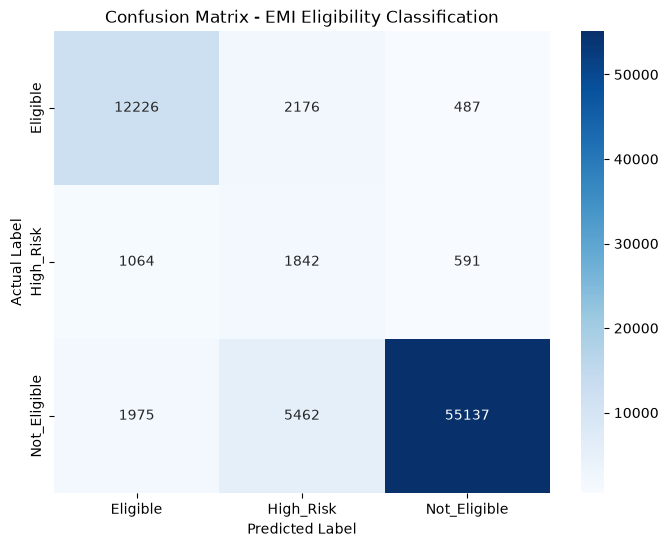

In [16]:
# confusion matrix

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(y_class_test, y_class_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classification_model.classes_,
    yticklabels=classification_model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - EMI Eligibility Classification")
plt.show()

In [17]:
# Final model evaluation comparison

comparison = pd.DataFrame({
    "Model": [
        "EMI Eligibility Classification",
        "Maximum EMI Regression"
    ],
    "Metric": [
        "Accuracy",
        "R² Score"
    ],
    "Score": [
        accuracy,
        r2
    ]
})

print(comparison)

                            Model    Metric     Score
0  EMI Eligibility Classification  Accuracy  0.854805
1          Maximum EMI Regression  R² Score  0.957848


In [18]:
# Save evaluation results

evaluation_results = pd.DataFrame({
    "Metric": [
        "Classification Accuracy",
        "Regression MAE",
        "Regression MSE",
        "Regression RMSE",
        "Regression R2"
    ],
    "Value": [
        accuracy,
        mae,
        mse,
        rmse,
        r2
    ]
})

evaluation_results.to_csv("../reports/model_evaluation_results.csv", index=False)

print("Evaluation results saved successfully!")

Evaluation results saved successfully!


In [19]:
# Check classification model features

print("Number of classification features:",
      len(classification_model.feature_names_in_))

print("\nClassification features:")
for i, feature in enumerate(classification_model.feature_names_in_, 1):
    print(i, feature)

Number of classification features: 44

Classification features:
1 age
2 gender
3 marital_status
4 monthly_salary
5 years_of_employment
6 monthly_rent
7 family_size
8 dependents
9 school_fees
10 college_fees
11 travel_expenses
12 groceries_utilities
13 other_monthly_expenses
14 existing_loans
15 current_emi_amount
16 credit_score
17 bank_balance
18 emergency_fund
19 requested_amount
20 requested_tenure
21 education_Graduate
22 education_High School
23 education_Post Graduate
24 education_Professional
25 employment_type_Government
26 employment_type_Private
27 employment_type_Self-employed
28 employment_type_nan
29 company_type_Large Indian
30 company_type_MNC
31 company_type_Mid-size
32 company_type_Small
33 company_type_Startup
34 company_type_nan
35 house_type_Family
36 house_type_Own
37 house_type_Rented
38 house_type_nan
39 emi_scenario_E-commerce Shopping EMI
40 emi_scenario_Education EMI
41 emi_scenario_Home Appliances EMI
42 emi_scenario_Personal Loan EMI
43 emi_scenario_Vehicle 

In [20]:
# Check regression model features

print("Number of regression features:",
      len(regression_model.feature_names_in_))

print("\nRegression features:")
for i, feature in enumerate(regression_model.feature_names_in_, 1):
    print(i, feature)

Number of regression features: 44

Regression features:
1 age
2 gender
3 marital_status
4 monthly_salary
5 years_of_employment
6 monthly_rent
7 family_size
8 dependents
9 school_fees
10 college_fees
11 travel_expenses
12 groceries_utilities
13 other_monthly_expenses
14 existing_loans
15 current_emi_amount
16 credit_score
17 bank_balance
18 emergency_fund
19 requested_amount
20 requested_tenure
21 education_Graduate
22 education_High School
23 education_Post Graduate
24 education_Professional
25 employment_type_Government
26 employment_type_Private
27 employment_type_Self-employed
28 employment_type_nan
29 company_type_Large Indian
30 company_type_MNC
31 company_type_Mid-size
32 company_type_Small
33 company_type_Startup
34 company_type_nan
35 house_type_Family
36 house_type_Own
37 house_type_Rented
38 house_type_nan
39 emi_scenario_E-commerce Shopping EMI
40 emi_scenario_Education EMI
41 emi_scenario_Home Appliances EMI
42 emi_scenario_Personal Loan EMI
43 emi_scenario_Vehicle EMI
44 e